## RFM - Recency Frequency Monetary
RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in retail and professional services industries.

#### RFM stands for the three dimensions:

* **Recency** – How recently did the customer purchase?
* **Frequency** – How often do they purchase?
* **Monetary Value** – How much do they spend?

Customer purchases may be represented by a table with columns for the customer name, date of purchase and purchase value. One approach to RFM is to assign a score for each dimension on a scale from 1 to 10. The maximum score represents the preferred behavior and a formula could be used to calculate the three scores for each customer. For example, a service-based business could use these calculations:

- **Recency** = the maximum of "10 – the number of months that have passed since the customer last purchased" and 1
- **Frequency** = the maximum of "the number of purchases by the customer in the last 12 months (with a limit of 10)" and 1
- **Monetary** = the highest value of all purchases by the customer expressed as a multiple of some benchmark value

Alternatively, categories can be defined for each attribute. For instance, Recency might be broken into three categories: customers with purchases within the last 90 days; between 91 and 365 days; and longer than 365 days. Such categories may be derived from business rules or using data mining techniques to find meaningful breaks.

Once each of the attributes has appropriate categories defined, segments are created from the intersection of the values. If there were three categories for each attribute, then the resulting matrix would have twenty-seven possible combinations (one well-known commercial approach uses five bins per attributes, which yields 125 segments). Companies may also decide to collapse certain subsegments, if the gradations appear too small to be useful. The resulting segments can be ordered from most valuable (highest recency, frequency, and value) to least valuable (lowest recency, frequency, and value). Identifying the most valuable RFM segments can capitalize on chance relationships in the data used for this analysis. For this reason, it is highly recommended that another set of data be used to validate the results of the RFM segmentation process. Advocates of this technique point out that it has the virtue of simplicity: no specialized statistical software is required, and the results are readily understood by business people. In the absence of other targeting techniques, it can provide a lift in response rates for promotions.

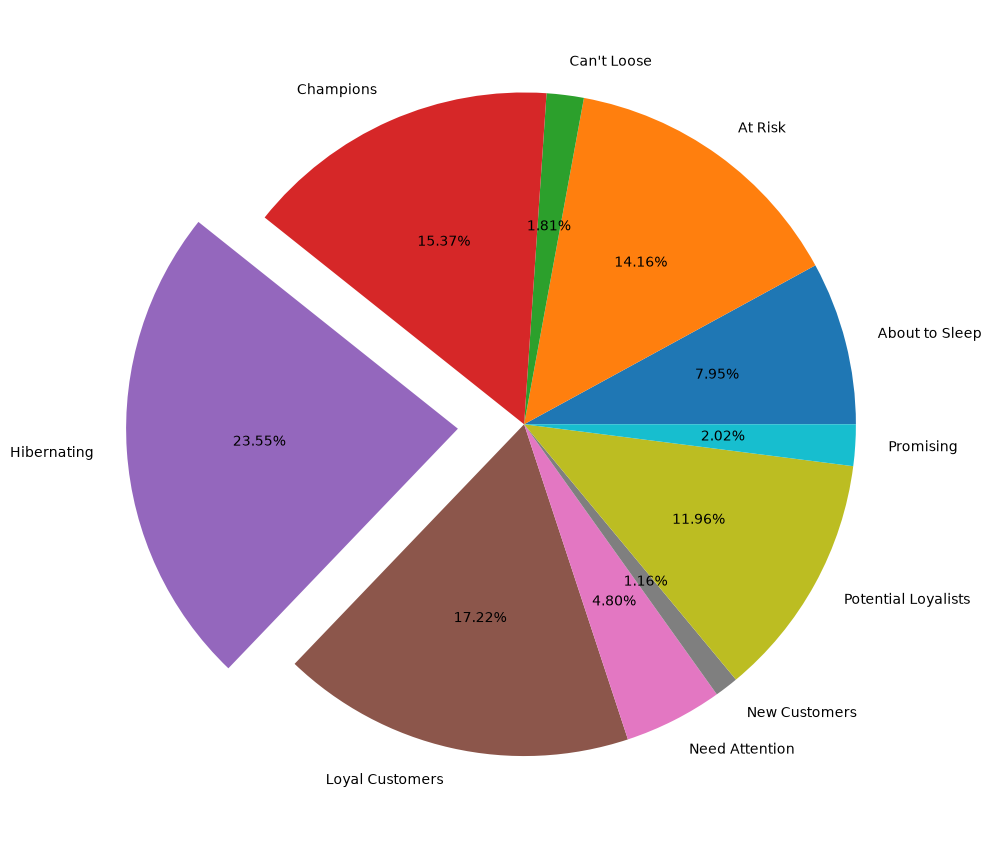
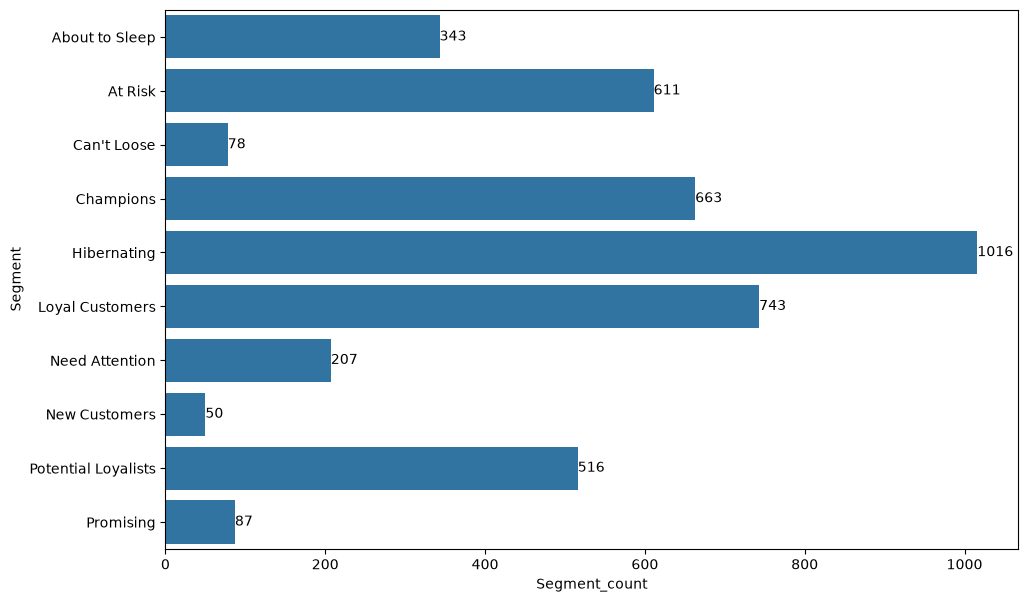

In [1]:
# import required modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from zipfile import ZipFile

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

colors = [
    "darkred",
    "navy",
    "darkgreen",
    "goldenrod",
    "deeppink",
    "darkorange",
    "firebrick",
    "indigo",
    "teal",
    "darkmagenta",
    "saddlebrown",
    'gray',
    'darkblue'
]

In [2]:
base_path = os.path.dirname(os.getcwd())


In [3]:
with ZipFile(rf'{base_path}\datasets\retail_ii.zip') as z:
    with z.open(r'online_retail_II.xlsx', 'r') as f:
        df = f.read()

df = pd.read_excel(df)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(525461, 8)

In [7]:
# Checking for the time duration of the dataset

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.InvoiceDate.max(), df.InvoiceDate.min()

(Timestamp('2010-12-09 20:01:00'), Timestamp('2009-12-01 07:45:00'))

## Missing Values

In [8]:
print('Missing Value Count:')
print(df.isnull().sum().sort_values(ascending=False), '\n')

print('Missing Values Proportion:')
print(df.isnull().sum().sort_values(ascending=False)/df.shape[0])

Missing Value Count:
Customer ID    107927
Description      2928
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64 

Missing Values Proportion:
Customer ID    0.205395
Description    0.005572
Invoice        0.000000
StockCode      0.000000
Quantity       0.000000
InvoiceDate    0.000000
Price          0.000000
Country        0.000000
dtype: float64


In [9]:
# drop nan values

print(f'Number of rows before droping nan: {df.shape[0]}\n')
df.dropna(inplace=True)
print(df.isnull().sum().sort_values(ascending=False), '\n')
print(f'Number of rows after droping nan: {df.shape[0]}')

Number of rows before droping nan: 525461

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64 

Number of rows after droping nan: 417534


# Statistic Summary and Outliers with Visuals

In [10]:
df.describe([0.01, 0.05, .10, .20, .30, .50, .70, .80, .90])

,Quantity,InvoiceDate,Price,Customer ID
count,417534.000000,417534,417534.000000,417534.000000
mean,12.758815,2010-07-01 01:12:19.787609856,3.887547,15360.645478
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000
1%,-2.000000,2009-12-02 15:04:00,0.290000,12435.000000
5%,1.000000,2009-12-13 12:42:00,0.420000,12725.000000
10%,1.000000,2010-01-18 14:49:00,0.650000,13042.000000
20%,1.000000,2010-03-05 09:09:00,0.850000,13624.000000
30%,2.000000,2010-04-19 12:45:00,1.250000,14256.000000
50%,4.000000,2010-07-08 19:12:00,1.950000,15311.000000
70%,10.000000,2010-10-03 10:51:00,2.950000,16549.000000


There are some negative values, which shows the returned items.

Invoice having 'C' in it are the returned entries

In [11]:
df = df[~df['Invoice'].str.contains('C', na=False)]

In [12]:
des = df.describe([.1, .2, .3, .5, .6, .7, .9])
des

,Quantity,InvoiceDate,Price,Customer ID
count,407695.000000,407695,407695.000000,407695.000000
mean,13.586686,2010-07-01 10:10:10.782177792,3.294188,15368.504107
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
10%,1.000000,2010-01-19 11:01:00,0.650000,13044.000000
20%,2.000000,2010-03-05 11:31:00,0.850000,13635.000000
30%,2.000000,2010-04-19 14:09:00,1.250000,14274.000000
50%,5.000000,2010-07-09 15:46:00,1.950000,15321.000000
60%,6.000000,2010-08-25 15:58:00,2.550000,15967.000000
70%,12.000000,2010-10-03 12:00:00,2.950000,16549.000000
90%,24.000000,2010-11-18 10:37:00,6.750000,17706.000000


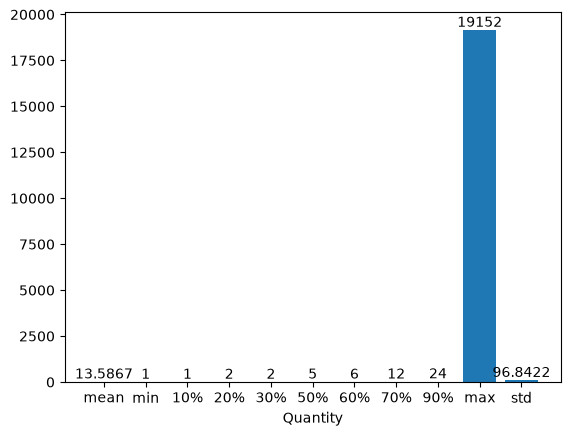

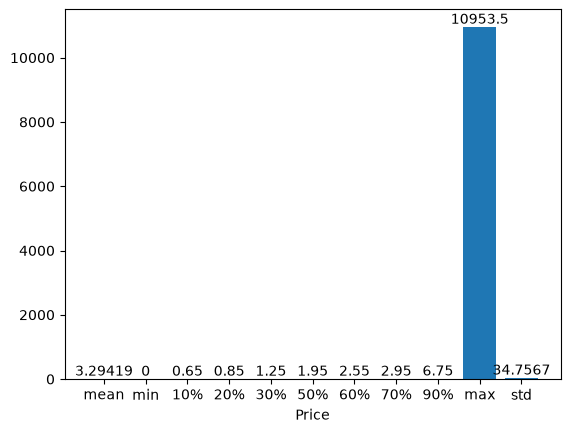

In [13]:
plt.Figure(figsize=(7, 5))
bar_plot = plt.bar(des.index[1:], des['Quantity'][1:])
plt.bar_label(bar_plot)
plt.xlabel('Quantity')
plt.show()

plt.Figure(figsize=(7, 5))
bar_plot = plt.bar(des.index[1:], des['Price'][1:])
plt.bar_label(bar_plot)
plt.xlabel('Price')
plt.show()

<Axes: >

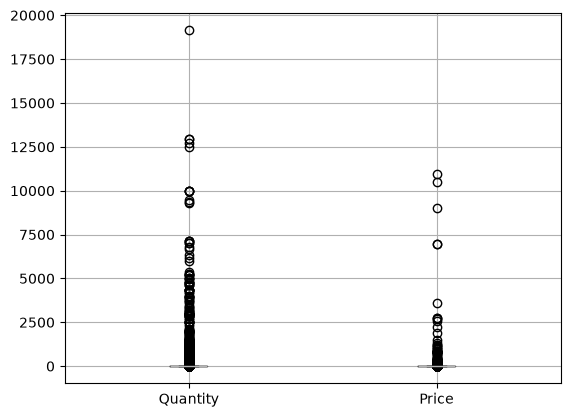

In [14]:
df[['Quantity', 'Price']].boxplot()

# RFM Analysis
---

## Recency

In [28]:
recency = (df['InvoiceDate'].max() - df.groupby('Customer ID').agg({'InvoiceDate': 'max'})).rename(columns={'InvoiceDate': 'Recency'})

In [29]:
recency['Recency'] = recency['Recency'].apply(lambda x: x.days)

In [30]:
recency

,Recency
Customer ID,
12346.0,164
12347.0,2
12348.0,73
12349.0,42
12351.0,10
...,...
18283.0,17
18284.0,66
18285.0,295


## Frequency

In [31]:
freq = df.groupby('Customer ID').agg({'InvoiceDate': 'nunique'}).rename(columns={'InvoiceDate': 'Frequency'})

In [32]:
freq

,Frequency
Customer ID,
12346.0,11
12347.0,2
12348.0,1
12349.0,3
12351.0,1
...,...
18283.0,6
18284.0,1
18285.0,1


## Monetary

In [33]:
df['TotalPrice'] = df['Quantity'] * df['Price']

monetary = df.groupby('Customer ID').agg({'TotalPrice':'sum'}).rename(columns={'TotalPrice':'Monetary'})

In [34]:
monetary

,Monetary
Customer ID,
12346.0,372.86
12347.0,1323.32
12348.0,222.16
12349.0,2671.14
12351.0,300.93
...,...
18283.0,641.77
18284.0,461.68
18285.0,427.00


In [35]:
# final rfm dataframe containing Recency, Frequency and Monetary of each customer

rfm = pd.concat([recency, freq, monetary], axis=1)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


# RFM Score

In [36]:
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])
rfm

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore
Customer ID,,,,,,
12346.0,164,11,372.86,2,5,2
12347.0,2,2,1323.32,5,2,4
12348.0,73,1,222.16,2,1,1
12349.0,42,3,2671.14,3,3,5
12351.0,10,1,300.93,5,1,2
...,...,...,...,...,...,...
18283.0,17,6,641.77,4,5,3
18284.0,66,1,461.68,3,2,2
18285.0,295,1,427.00,1,2,2


In [37]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = rfm['RecencyScore'].astype(str)+rfm['FrequencyScore'].astype(str)

rfm['Segment'] = rfm['Segment'].replace(seg_map, regex=True)

rfm['CustomerID'] = rfm.index.astype(int)
rfm.reset_index(drop=True, inplace=True)
rfm = rfm[['CustomerID','Recency','Frequency', 'Monetary','RecencyScore','FrequencyScore','MonetaryScore','Segment']]


In [38]:
rfm

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,Segment
0,12346,164,11,372.86,2,5,2,Can't Loose
1,12347,2,2,1323.32,5,2,4,Potential Loyalists
2,12348,73,1,222.16,2,1,1,Hibernating
3,12349,42,3,2671.14,3,3,5,Need Attention
4,12351,10,1,300.93,5,1,2,New Customers
...,...,...,...,...,...,...,...,...
4309,18283,17,6,641.77,4,5,3,Loyal Customers
4310,18284,66,1,461.68,3,2,2,About to Sleep
4311,18285,295,1,427.00,1,2,2,Hibernating
4312,18286,111,2,1296.43,2,3,4,At Risk


## Summary of RFM

In [40]:
rfmSummary = rfm[['Segment', 'Recency', 'Frequency', 'Monetary']].groupby('Segment').agg(['mean', 'median', 'std'])

rfmSummary.columns = rfmSummary.columns.map('_'.join).str.strip('|')

rfmSummary['Segment'] = rfmSummary.index
rfmSummary['Segment_count'] = rfm['Segment'].value_counts()
rfmSummary = rfmSummary.reset_index(drop=True)

rfmSummary[['Segment', 'Recency_mean', 'Recency_median', 'Recency_std','Frequency_mean','Frequency_median', 'Frequency_std', 'Monetary_mean', 'Monetary_median', 'Monetary_std', 'Segment_count']]

,Segment,Recency_mean,Recency_median,Recency_std,Frequency_mean,Frequency_median,Frequency_std,Monetary_mean,Monetary_median,Monetary_std,Segment_count
0,About to Sleep,52.851312,52.0,10.259985,1.201166,1.0,0.401458,442.266851,317.760,417.303449,343
1,At Risk,150.934534,129.0,69.976031,3.070376,3.0,1.092428,1188.207056,760.190,1844.174551,611
2,Can't Loose,122.717949,107.5,49.724409,9.038462,7.5,5.782738,4072.967051,2316.485,5275.397061,78
3,Champions,6.119155,6.0,4.619934,12.499246,8.0,17.189180,6852.264167,2508.320,21556.377144,663
4,Hibernating,213.308071,212.0,89.780194,1.126969,1.0,0.333102,401.982150,250.155,775.076212,1016
5,Loyal Customers,35.275908,30.0,16.064746,6.816958,5.0,4.376349,2743.484342,1818.710,3255.108992,743
6,Need Attention,52.212560,52.0,9.838168,2.454106,2.0,0.499096,1058.788068,730.470,1190.255349,207
7,New Customers,7.580000,7.5,4.309884,1.000000,1.0,0.000000,386.199200,258.825,493.321262,50
8,Potential Loyalists,17.773256,18.0,9.730991,2.023256,2.0,0.696344,729.164806,523.660,837.546248,516
9,Promising,24.758621,24.0,6.030862,1.000000,1.0,0.000000,368.020690,293.740,343.912746,87


## Visalize the outputs

In [41]:
rfmSummary.columns, rfmSummary.index

(Index(['Recency_mean', 'Recency_median', 'Recency_std', 'Frequency_mean',
        'Frequency_median', 'Frequency_std', 'Monetary_mean', 'Monetary_median',
        'Monetary_std', 'Segment', 'Segment_count'],
       dtype='object'),
 RangeIndex(start=0, stop=10, step=1))

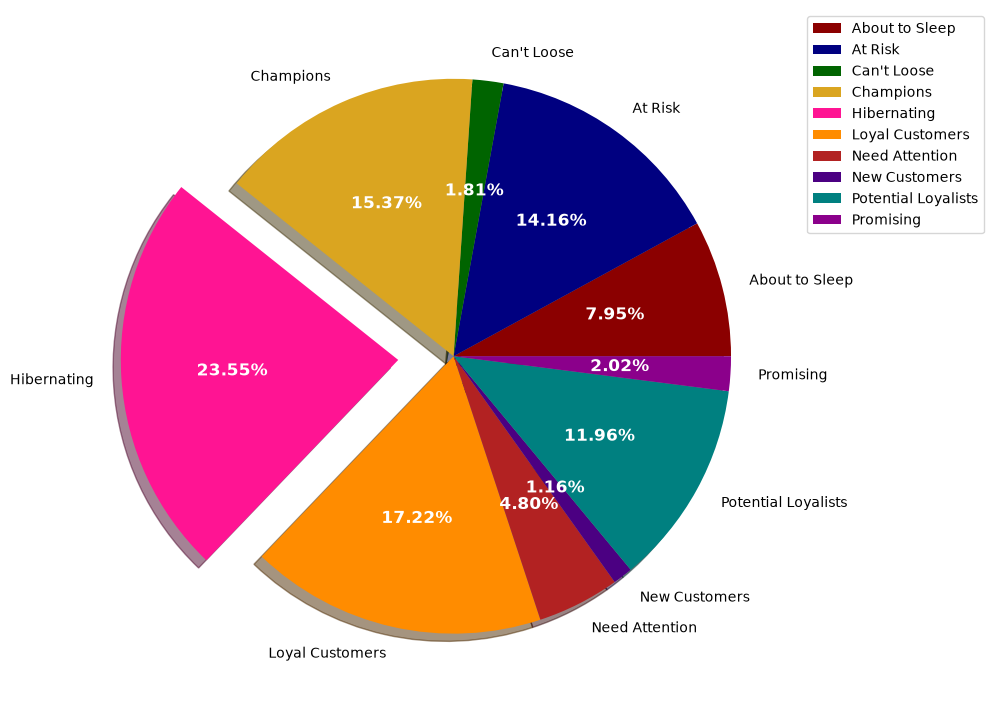

In [42]:
# pie chart
explode = [0]*len(rfmSummary['Segment_count'])
explode[rfmSummary['Segment_count'].idxmax()] = 0.2

plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(
    x=rfmSummary['Segment_count'],
    labels=rfmSummary['Segment'],
    autopct='%.2f%%',
    explode=explode,
    shadow=True,
    colors=colors
)

# Change percentage text color to white
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)

plt.legend(loc="upper left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

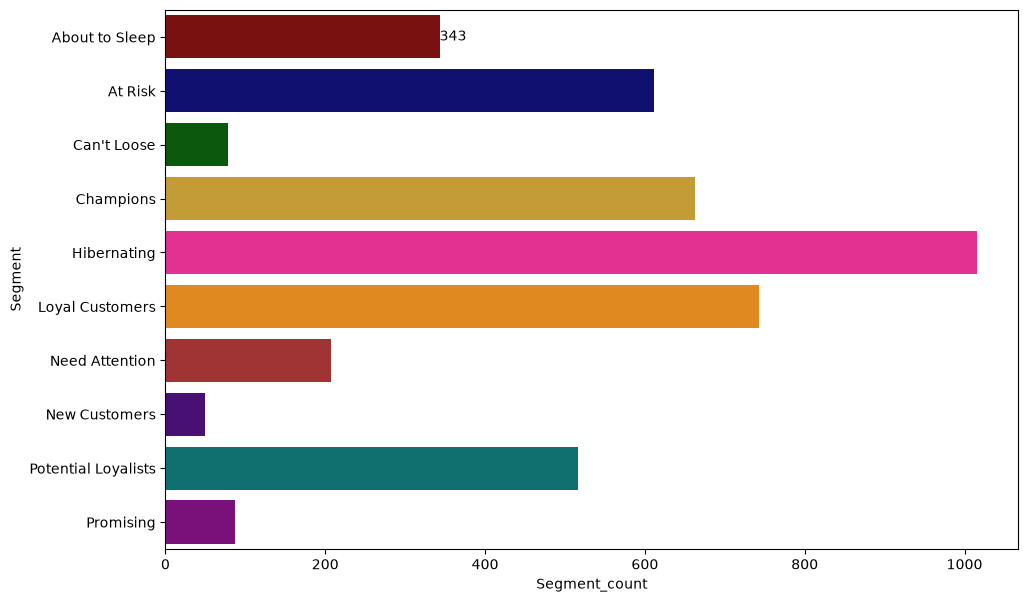

In [44]:
plt.figure(figsize=(11, 7))
bar_plot = sns.barplot(data=rfmSummary, x='Segment_count', y='Segment', palette=colors)
bar_plot.bar_label(bar_plot.containers[0], fmt='%d')
plt.show()